In [193]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from scipy.optimize import curve_fit

root2pi = np.sqrt(2*np.pi)

In [2]:
data = pd.read_csv("all_humsaver_enrich_txt_h.csv", names=["L","H","dSNPs", "nSNPs", "SNPs", "Enrich", "p"], skiprows=1)

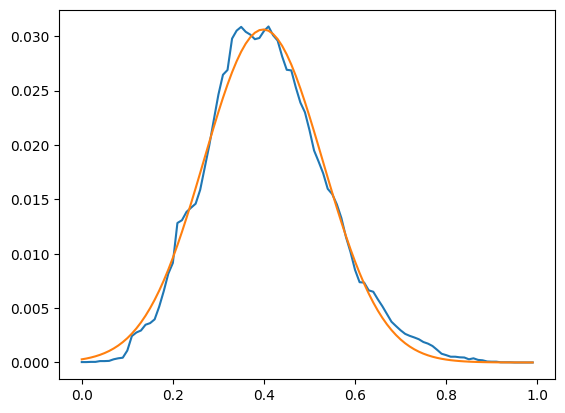

In [128]:
mask = data.L==6

Ys = data.loc[mask,"dSNPs"]
Ys=list(Ys/np.sum(Ys))

Xs = list(data.loc[mask, "H"])

root2pi = np.sqrt(2*np.pi)
from scipy.stats import norm
def fitfunc(X, mu, sigma):
    return norm.cdf(X, mu, sigma)

[[mu, sigma], variance] = curve_fit(fitfunc, Xs, np.cumsum(Ys))
fitted = norm.pdf(Xs, mu, sigma)
fitted = fitted/np.sum(fitted)

plt.plot(Xs, Ys)
plt.plot(Xs, fitted)

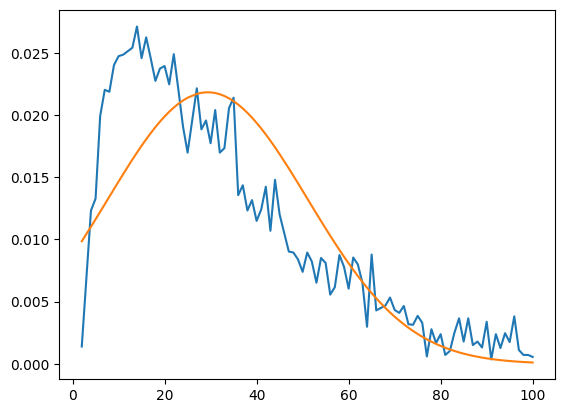

In [134]:
mask = data.H==0.2

Ys = data.loc[mask,"dSNPs"]
Ys=list(Ys/np.sum(Ys))

Xs = list(data.loc[mask, "L"])

root2pi = np.sqrt(2*np.pi)
from scipy.stats import norm
def fitfunc(X, mu, sigma):
    return norm.cdf(X, mu, sigma)

[[mu, sigma], variance] = curve_fit(fitfunc, Xs, np.cumsum(Ys))
fitted = norm.pdf(Xs, mu, sigma)
fitted = fitted/np.sum(fitted)

plt.plot(Xs, Ys)
plt.plot(Xs, fitted)

# First Order

In [196]:
mask = data.H<=1


Ys = data.loc[mask,"dSNPs"]
Ys=Ys/np.sum(Ys)

Xs = data.loc[mask, ["H", "L"]]

root2pi = np.sqrt(2*np.pi)
from scipy.stats import norm
def fitfunc(X, mu, sigma):
    return norm.cdf(X['H']**2+2*X['H']*X['L']*sigma+X['L']**2, mu, sigma)

def plotfunc(X, mu, sigma):
    return norm.pdf(X['H']**2+2*X['H']*X['L']*sigma+X['L']**2, mu, sigma)


[mu, sigma], variance = curve_fit(fitfunc, Xs, np.cumsum(Ys), method='dogbox')


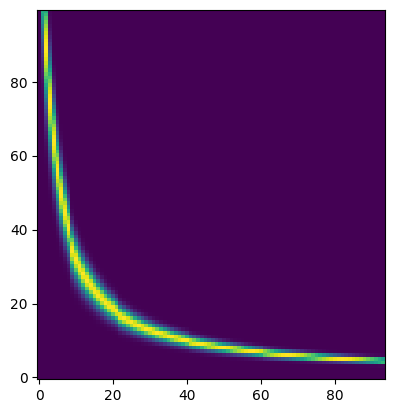

In [197]:
fitted = [[plotfunc({'L':L,'H':H}, mu, sigma) for L in Ls] for H in Hs]
plt.imshow(fitted, origin='lower')

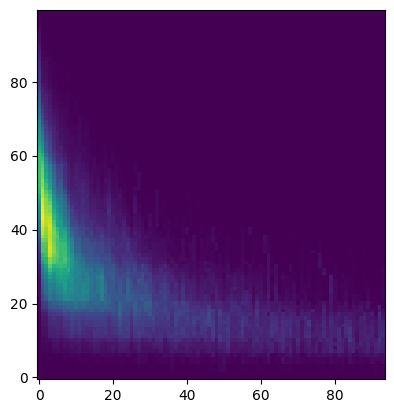

In [175]:
Hs = Xs['H'].unique()
Ls = Xs['L'].unique()

histgrid = [[data.loc[np.logical_and(data.H==H,data.L==L), 'dSNPs'] for L in Ls] for H in Hs]
plt.imshow(histgrid, origin='lower')

# Second order

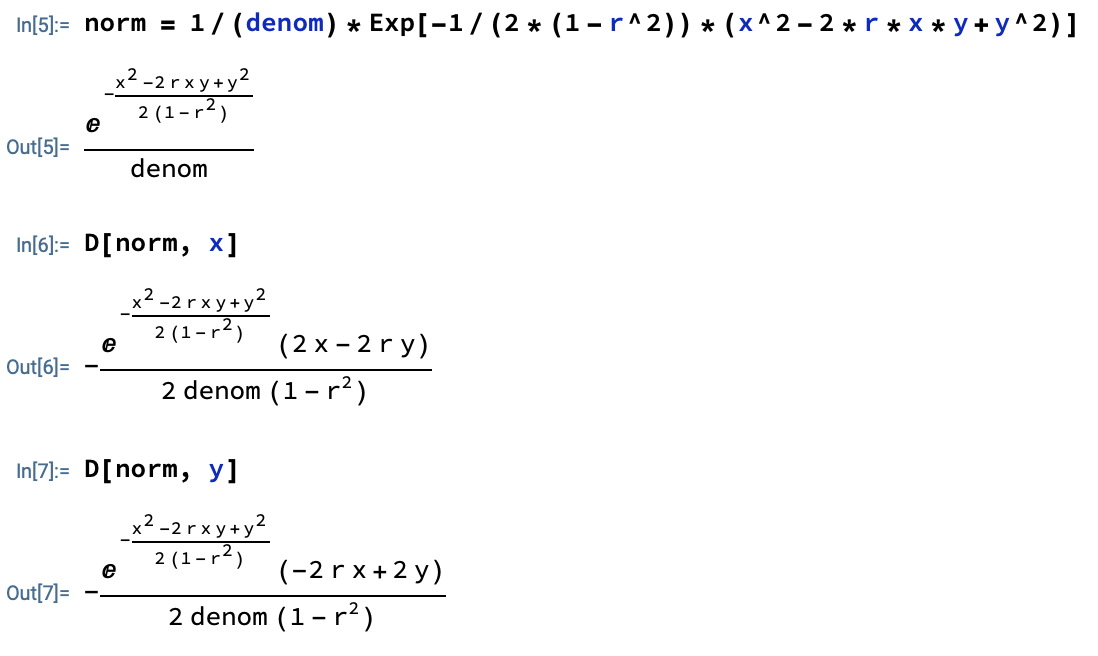

In [204]:
mask = data.H<=1


Ys = data.loc[mask,"dSNPs"]
Ys=Ys/np.sum(Ys)

Xs = data.loc[mask, ["H", "L"]]

root2pi = np.sqrt(2*np.pi)
from scipy.stats import norm
def fitfunc(X, mu, sigma):
    normTerm = norm.pdf(X['H']**2+2*X['H']*X['L']*sigma+X['L']**2, mu, sigma)
    normalizer = -normTerm/(2*(1-sigma**2))
    Hterm = (2*X['H']-2*sigma*X['L'])
    Lterm = (2*X['L']-2*sigma*X['H'])
    return normTerm + (Hterm + Lterm)*normalizer

def plotfunc(X, mu, sigma):
    normTerm = norm.pdf(X['H']**2+2*X['H']*X['L']*sigma+X['L']**2, mu, sigma)
    normalizer = -normTerm/(2*(1-sigma**2))
    Hterm = (2*X['H']-2*sigma*X['L'])
    Lterm = (2*X['L']-2*sigma*X['H'])
    return normTerm + (Hterm + Lterm)*normalizer


[mu, sigma], variance = curve_fit(fitfunc, Xs, np.cumsum(Ys), method='trf', bounds=([0,0.01],[np.inf,np.inf]))


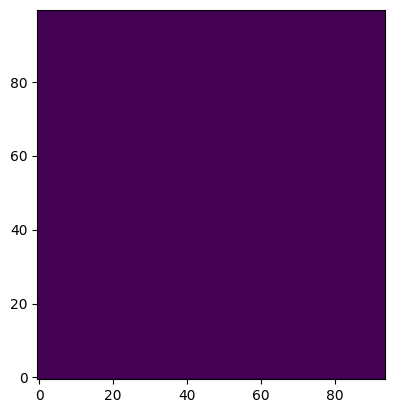

In [205]:
fitted = [[plotfunc({'L':L,'H':H}, mu, sigma) for L in Ls] for H in Hs]
plt.imshow(fitted, origin='lower')